In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pytest
import ipytest
ipytest.autoconfig()

In [16]:
dataset_size = 100

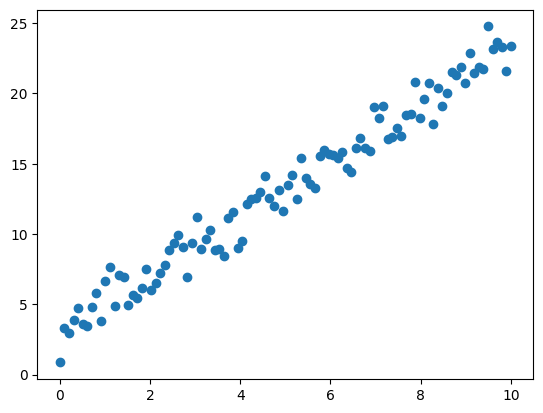

In [17]:
# Первый датасет
x1 = np.linspace(0, 10, dataset_size)
a1 = 3
b1 = 2
noise1 = np.random.normal(0, 1, dataset_size)
y1 = a1 + b1 * x1 + noise1
pd.DataFrame({'x': x1, 'y': y1}).to_csv(f'dataset_{1}.csv', index=False)
plt.scatter(x1, y1)
plt.show()

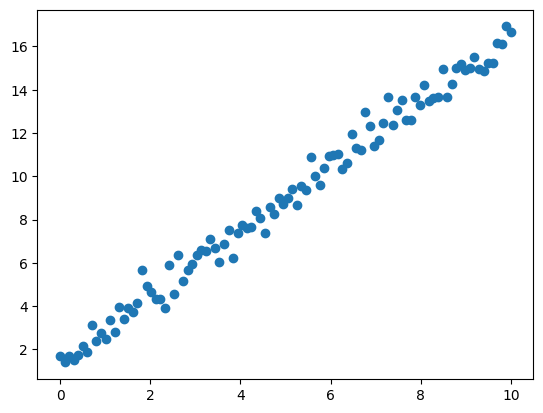

In [18]:
# Второй датасет
x2 = np.linspace(0, 10, dataset_size)
a2 = 1.5
b2 = 1.5
noise2 = np.random.normal(0, 0.5, dataset_size)
y2 = a2 + b2 * x2 + noise2
pd.DataFrame({'x': x2, 'y': y2}).to_csv(f'dataset_{2}.csv', index=False)
plt.scatter(x2, y2)
plt.show()

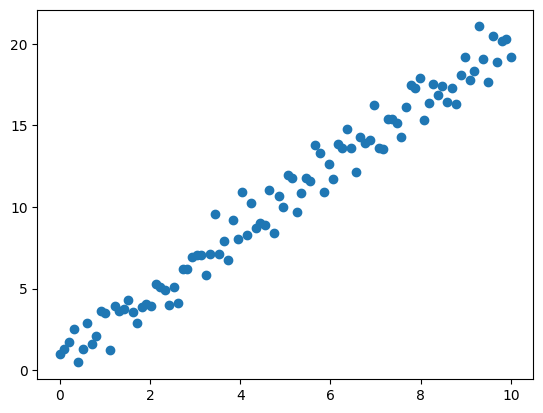

In [19]:
# Третий датасет
x3 = np.linspace(0, 10, dataset_size)
a3 = 0.5
b3 = 2
noise3 = np.random.normal(0, 1, dataset_size)
y3 = a3 + b3 * x3 + noise3
pd.DataFrame({'x': x3, 'y': y3}).to_csv(f'dataset_{3}.csv', index=False)
plt.scatter(x3, y3)
plt.show()

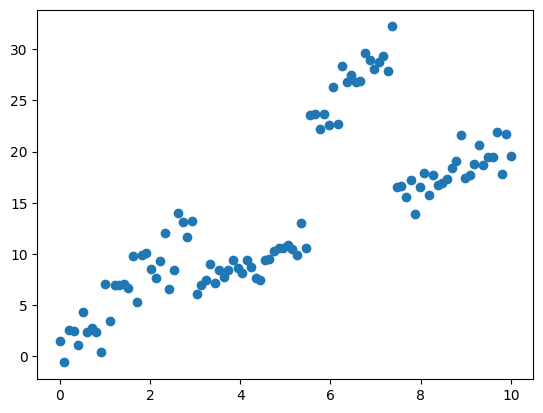

In [20]:
# Третий датасет
x4 = np.linspace(0, 10, dataset_size)
a4 = 0.5
b4 = 2
noise4 = np.random.normal(0, 1, dataset_size)
y4 = a4 + b4 * x4 + noise4
y4[10:30] *= 2
y4 [55:74] *= 2
pd.DataFrame({'x': x4, 'y': y4}).to_csv(f'dataset_{4}.csv', index=False)
plt.scatter(x4, y4)
plt.show()

In [21]:
model = LinearRegression()

In [22]:
df1 = pd.read_csv("dataset_4.csv")
x = df1[['x']]
y = df1[['y']]
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

pred_r2_score = r2_score(y_test, pred)
print(f"R2 score: {pred_r2_score}")

R2 score: 0.595217534112832


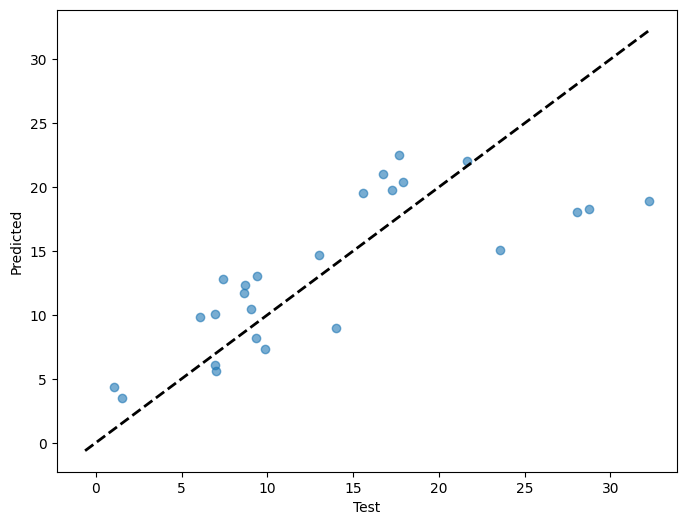

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Test')
plt.ylabel('Predicted')
plt.show()

In [24]:
@pytest.mark.parametrize(
    "file",
    [
        ("dataset_1.csv"),
        ("dataset_2.csv"),
        ("dataset_3.csv"),
        ("dataset_4.csv"),
    ],
)

def test_dataset(file):
    df = pd.read_csv(file)
    x = df[['x']]
    y = df[['y']]
    X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred_r2_score = r2_score(y_test, pred)
    #print(f"R2 score: {pred_r2_score}")
    assert pred_r2_score > 0.9

ipytest.run()

...F                                                                                         [100%]
============================================ FAILURES =============================================
___________________________________ test_dataset[dataset_4.csv] ___________________________________

file = 'dataset_4.csv'

    @pytest.mark.parametrize(
        "file",
        [
            ("dataset_1.csv"),
            ("dataset_2.csv"),
            ("dataset_3.csv"),
            ("dataset_4.csv"),
        ],
    )
    
    def test_dataset(file):
        df = pd.read_csv(file)
        x = df[['x']]
        y = df[['y']]
        X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        pred_r2_score = r2_score(y_test, pred)
        #print(f"R2 score: {pred_r2_score}")
>       assert pred_r2_score > 0.9
E       assert 0.595217534112832 > 0.9

C:\Users\Acer\AppData\Local\Temp\ipykernel_1678

<ExitCode.TESTS_FAILED: 1>